In [63]:
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

from model import TransformerModel
from train import MODEL_DIMS, MODEL_POSITIONS, MODEL_EMBED_DIM, MODEL_ATT_LAYERS, MODEL_ATT_HEADS
from data_sampler import sample_linear_regression_task

from sklearn.linear_model import Lasso

In [64]:
def load_model(state_path, device = None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = TransformerModel(
        n_dims = MODEL_DIMS,
        n_positions = MODEL_POSITIONS,
        n_embd = MODEL_EMBED_DIM,
        n_layer = MODEL_ATT_LAYERS,
        n_head = MODEL_ATT_HEADS,
    ).to(device)

    state = torch.load(state_path, map_location = device)
    state_dict = state["model_state_dict"]
    
    model.load_state_dict(state_dict, strict = False)
    model.eval()
    
    return model

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [66]:
def least_squares_baseline(samples, n_points, n_dims, sparsity = None):
    losses = []
    denom = sparsity if sparsity else n_dims
    
    for _ in tqdm(range(samples)):
        xs, ys, w = sample_linear_regression_task(
            batch_size = 1,
            n_points = n_points,
            n_dims = n_dims,
            device = device,
            n_dims_trunc = n_dims,
            sparsity = sparsity
        )
        xs, ys = xs[0], ys[0]

        mses = []
        for i in range(len(xs)):
            X, y = xs[:i], ys[:i]
            x_query = xs[i].cpu().numpy()
            y_query = ys[i].cpu().numpy()
            
            # min-norm least squares estimator
            w_hat = np.linalg.lstsq(X, y, rcond = None)[0]
            y_pred = x_query @ w_hat

            # calculate mse divided by the number of nonzero weights
            mse = (y_pred - y_query) ** 2 / denom
            mses.append(mse)
        
        losses.append(mses)
    
    return np.mean(losses, axis = 0)

In [71]:
def lasso_baseline(samples, n_points, n_dims, sparsity = None):
    losses = []
    denom = sparsity if sparsity else n_dims
    
    for _ in tqdm(range(samples)):
        xs, ys, w = sample_linear_regression_task(
            batch_size = 1,
            n_points = n_points,
            n_dims = n_dims,
            device = device,
            n_dims_trunc = n_dims,
            sparsity = sparsity
        )
        xs, ys = xs[0], ys[0]

        mses = []
        for i in range(1, len(xs)):
            X, y = xs[:i], ys[:i]
            x_query = xs[i].cpu().numpy()
            y_query = ys[i].cpu().numpy()

            # convert to numpy for sklearn
            X_np = X.cpu().numpy()
            y_np = y.cpu().numpy().reshape(-1)
            
            # lasso estimator
            lasso = Lasso(
                alpha = 0.1,
                fit_intercept = False,
                max_iter = 10_000
            )
            lasso.fit(X_np, y_np)
            y_pred = lasso.predict(x_query[None, :])[0]

            # calculate mse divided by the number of nonzero weights
            mse = (y_pred - y_query) ** 2 / denom
            mses.append(mse)
        
        losses.append(mses)
    
    return np.mean(losses, axis = 0)

In [ ]:
@torch.no_grad()
def eval_model(model, n_points, n_dims, num_batches, batch_size, sparsity = None):
    device = next(model.parameters()).device
    model.eval()

    denom = sparsity if sparsity else n_dims
    mses = 0.0 

    for _ in tqdm(range(num_batches)):
        xs, ys, w = sample_linear_regression_task(
            batch_size = batch_size,
            n_points = n_points,
            n_dims = n_dims,
            device = device,
            n_dims_trunc = n_dims,
            sparsity = sparsity
        )

        preds = model(xs, ys)
        sq_err = (preds - ys) ** 2 / denom

        mses += sq_err.sum(dim = 0)

    losses = (mses / (num_batches * batch_size)).cpu().numpy()

    return losses

100%|██████████| 10000/10000 [00:22<00:00, 446.90it/s]


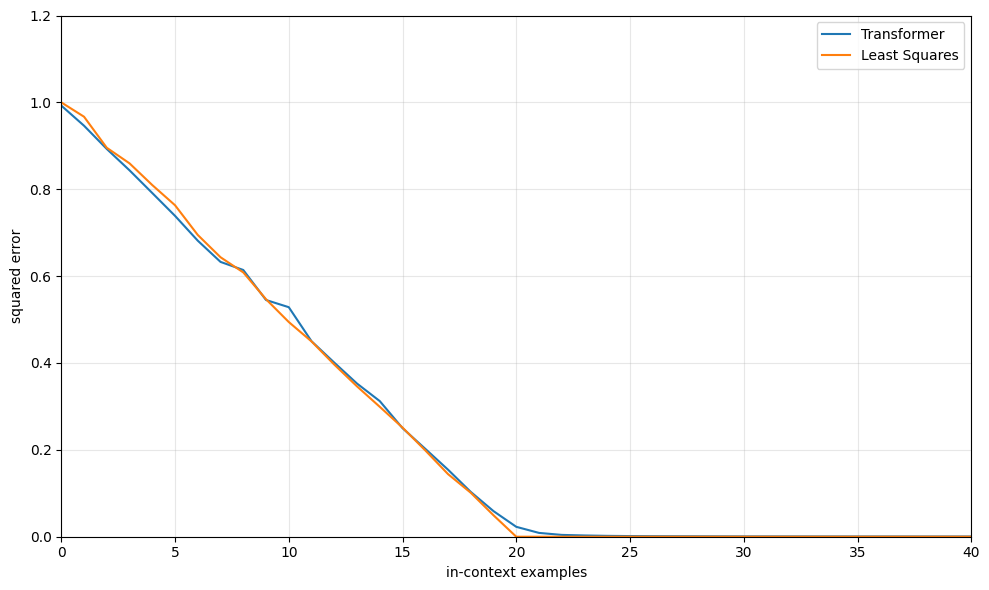

In [54]:
model = load_model("models/underparameterized_linear_regression/state.pt")

model_mses = eval_model(
    model,
    n_points = 41,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = None
)

lstsq_mses = least_squares_baseline(
    samples = 64 * 100,
    n_points = 41,
    n_dims = 20
)

plt.figure(figsize = (10, 6))
plt.plot(np.arange(len(model_mses)), model_mses, label = "Transformer")
plt.plot(np.arange(len(lstsq_mses)), lstsq_mses, label = "Least Squares")
plt.xlabel("in-context examples")
plt.ylabel("squared error")
plt.ylim(0.0, 1.2)
plt.xlim(0, 40)
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

100%|██████████| 6400/6400 [00:03<00:00, 2129.32it/s]


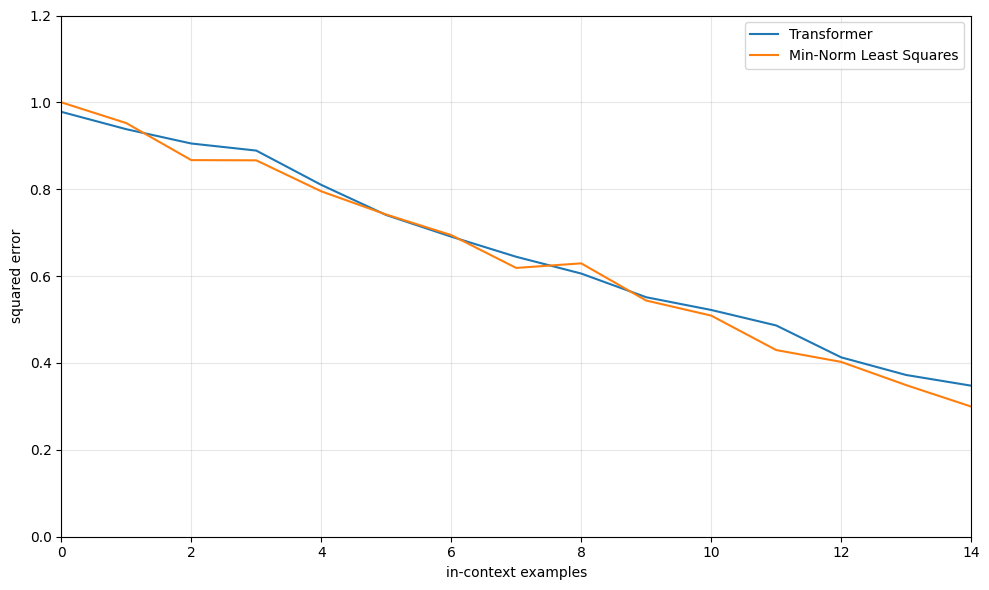

In [61]:
model = load_model("models/overparameterized_linear_regression/state.pt")

model_mses = eval_model(
    model,
    n_points = 15,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = None
)

lstsq_mses = least_squares_baseline(
    samples = 64 * 100,
    n_points = 15,
    n_dims = 20
)

plt.figure(figsize = (10, 6))
plt.plot(np.arange(len(model_mses)), model_mses, label = "Transformer")
plt.plot(np.arange(len(lstsq_mses)), lstsq_mses, label = "Min-Norm Least Squares")
plt.xlabel("in-context examples")
plt.ylabel("squared error")
plt.ylim(0.0, 1.2)
plt.xlim(0, 14)
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

100%|██████████| 6400/6400 [00:26<00:00, 237.40it/s]


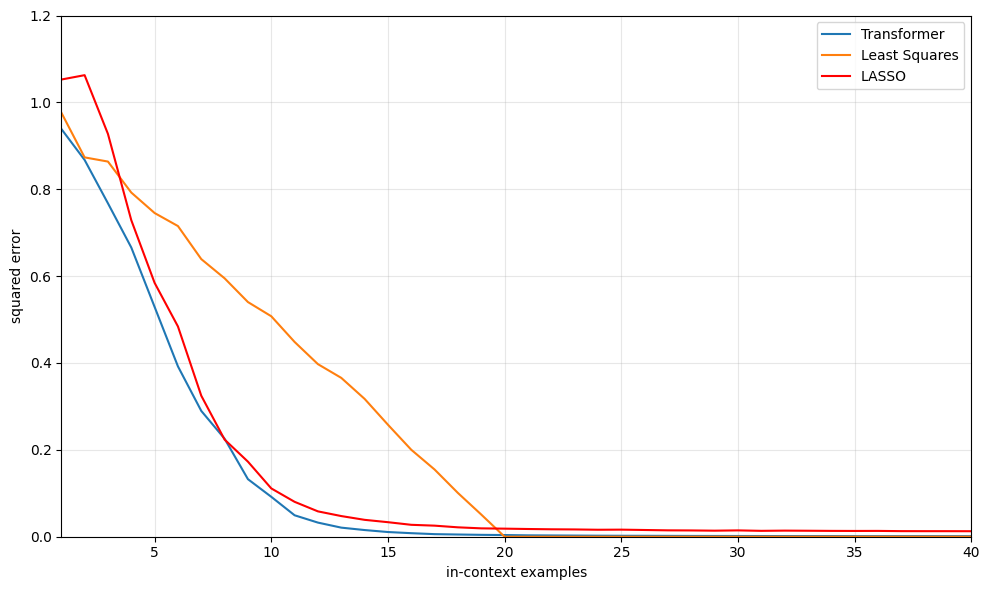

In [77]:
model = load_model("models/sparse_linear_regression/state.pt")

model_mses = eval_model(
    model,
    n_points = 41,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = 3
)

lstsq_mses = least_squares_baseline(
    samples = 64 * 100,
    n_points = 41,
    n_dims = 20,
    sparsity = 3
)

lasso_mses = lasso_baseline(
    samples = 64 * 100,
    n_points = 41,
    n_dims = 20,
    sparsity = 3
)

plt.figure(figsize = (10, 6))
plt.plot(np.arange(1, len(model_mses)), model_mses[1:], label = "Transformer")
plt.plot(np.arange(1, len(lstsq_mses)), lstsq_mses[1:], label = "Least Squares")
plt.plot(np.arange(1, len(lasso_mses) + 1), lasso_mses, label = "LASSO", color = "red")
plt.xlabel("in-context examples")
plt.ylabel("squared error")
plt.ylim(0.0, 1.2)
plt.xlim(1, 40)
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()